In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/patelris/pokemon-dataset-with-stats-and-types/pokemon_types.csv
/kaggle/input/datasets/patelris/pokemon-dataset-with-stats-and-types/pokemon_complete.csv


In [2]:
# !pip install pandas numpy matplotlib seaborn scikit-learn networkx

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import networkx as nx

sns.set(style="whitegrid")

In [3]:
pokemon = pd.read_csv("/kaggle/input/datasets/patelris/pokemon-dataset-with-stats-and-types/pokemon_complete.csv")
types = pd.read_csv("/kaggle/input/datasets/patelris/pokemon-dataset-with-stats-and-types/pokemon_types.csv")

In [4]:
# Fill missing type_2
pokemon["type_2"] = pokemon["type_2"].fillna("None")

# Power index (custom metric 🔥)
pokemon["power_index"] = (
    pokemon["attack"] * 0.25 +
    pokemon["sp_attack"] * 0.25 +
    pokemon["speed"] * 0.2 +
    pokemon["defense"] * 0.15 +
    pokemon["sp_defense"] * 0.15
)

# Bulk index (tankiness)
pokemon["bulk_index"] = (
    pokemon["hp"] + pokemon["defense"] + pokemon["sp_defense"]
)

# Efficiency
pokemon["efficiency"] = pokemon["base_stat_total"] / pokemon["weight_kg"]

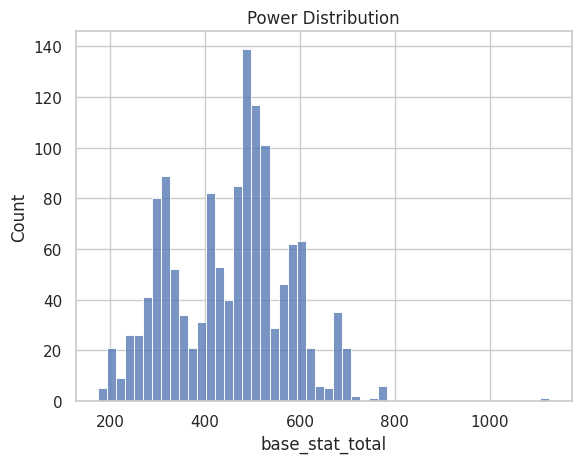

In [5]:
sns.histplot(pokemon["base_stat_total"], bins=50)
plt.title("Power Distribution")
plt.show()

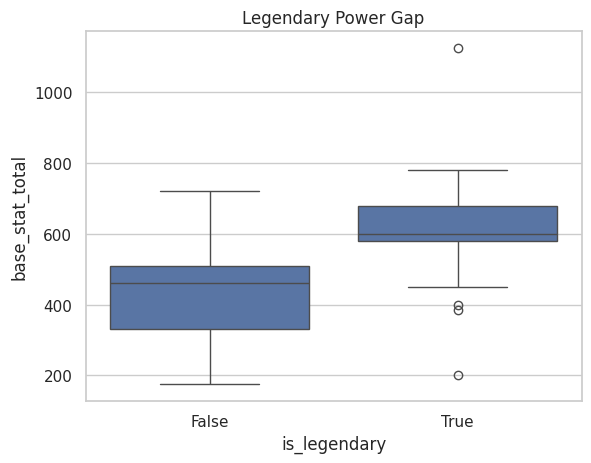

In [6]:
sns.boxplot(x="is_legendary", y="base_stat_total", data=pokemon)
plt.title("Legendary Power Gap")
plt.show()

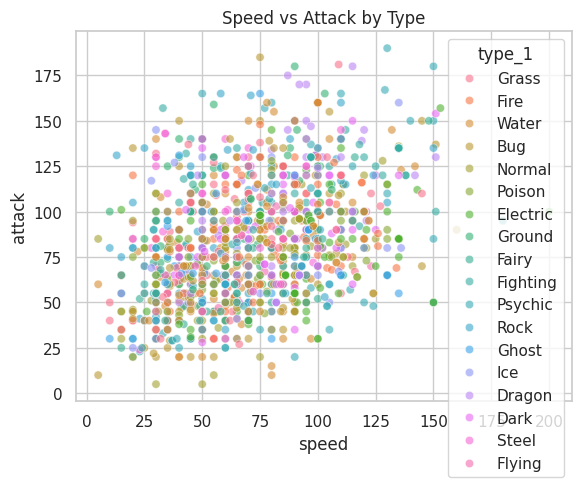

In [7]:
sns.scatterplot(
    x="speed",
    y="attack",
    hue="type_1",
    data=pokemon,
    alpha=0.6
)
plt.title("Speed vs Attack by Type")
plt.show()

In [8]:
features = ["hp","attack","defense","sp_attack","sp_defense","speed"]

scaler = StandardScaler()
scaled = scaler.fit_transform(pokemon[features])

kmeans = KMeans(n_clusters=5)
pokemon["cluster"] = kmeans.fit_predict(scaled)

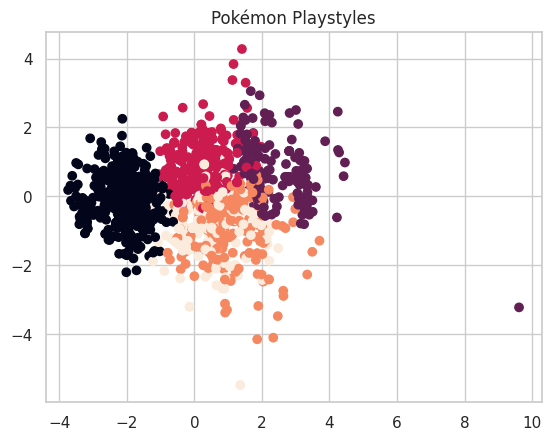

In [9]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled)

plt.scatter(pca_data[:,0], pca_data[:,1], c=pokemon["cluster"])
plt.title("Pokémon Playstyles")
plt.show()

In [10]:
def parse_types(x):
    return [] if pd.isna(x) else x.split("|")

types["double_damage_to"] = types["double_damage_to"].apply(parse_types)

type_chart = {
    row["type"]: row["double_damage_to"]
    for _, row in types.iterrows()
}


In [11]:
def matchup(attacker, defender):
    advantages = type_chart.get(attacker, [])
    return 2 if defender in advantages else 1

In [12]:
def team_score(team):
    score = 0
    
    for i in range(len(team)):
        for j in range(i+1, len(team)):
            score += matchup(team[i]["type_1"], team[j]["type_1"])
    
    return score

In [13]:
top_power = pokemon.sort_values("power_index", ascending=False).head(10)
top_power[["name","type_1","power_index"]]

,name,type_1,power_index
1214,Eternatus-Eternamax,Poison,161.00
1103,Rayquaza-Mega,Dragon,143.00
1068,Mewtwo-Mega-Y,Psychic,142.50
1067,Mewtwo-Mega-X,Psychic,142.00
1181,Necrozma-Ultra,Psychic,138.40
1102,Groudon-Primal,Ground,138.00
1101,Kyogre-Primal,Water,138.00
1099,Diancie-Mega,Rock,135.00
1343,Zeraora-Mega,Electric,129.85
1087,Latios-Mega,Dragon,127.50


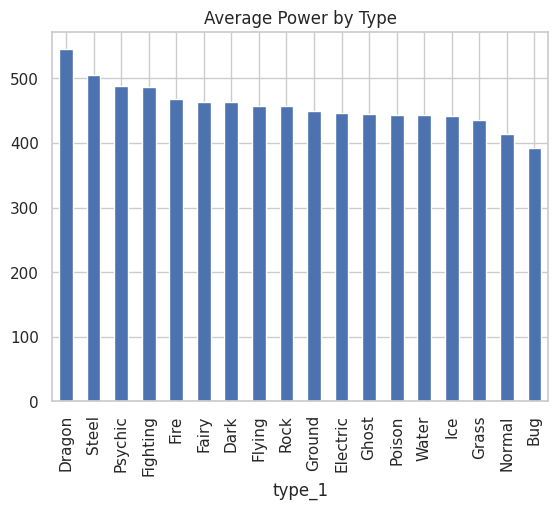

In [14]:
type_power = pokemon.groupby("type_1")["base_stat_total"].mean()
type_power.sort_values(ascending=False).plot(kind="bar")
plt.title("Average Power by Type")
plt.show()

In [15]:
legendary_ratio = pokemon.groupby("type_1")["is_legendary"].mean()
legendary_ratio.sort_values(ascending=False)

type_1
Dragon      0.305085
Psychic     0.247059
Fighting    0.209677
Flying      0.153846
Fairy       0.142857
Electric    0.110000
Poison      0.096154
Dark        0.095238
Ground      0.080000
Steel       0.076923
Ice         0.068182
Fire        0.059524
Ghost       0.057692
Grass       0.049180
Normal      0.043165
Water       0.037500
Rock        0.024096
Bug         0.000000
Name: is_legendary, dtype: float64

In [16]:
best_score = 0
best_team = None

for _ in range(2000):
    team = pokemon.sample(6).to_dict("records")
    score = team_score(team)
    
    if score > best_score:
        best_score = score
        best_team = team

print("🔥 Best Team:")
for p in best_team:
    print(p["name"], "-", p["type_1"])

🔥 Best Team:
Landorus-Incarnate - Ground
Noibat - Flying
Furret - Normal
Poliwhirl - Water
Absol - Dark
Fennekin - Fire


In [17]:
def parse(x):
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return []
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        return x.split("|")
    return []

In [18]:
cols = [
    "double_damage_to", "half_damage_to", "no_damage_to",
    "double_damage_from", "half_damage_from", "no_damage_from"
]

for col in cols:
    types[col] = types[col].apply(parse)

In [19]:
type_chart = {}

for _, row in types.iterrows():
    type_chart[row["type"]] = {
        "strong": row["double_damage_to"],
        "weak": row["half_damage_to"],
        "immune": row["no_damage_to"]
    }

In [20]:
def type_multiplier(attacker_type, defender_type1, defender_type2=None):
    chart = type_chart.get(attacker_type, {})
    
    def single(def_type):
        if def_type in chart.get("immune", []):
            return 0
        elif def_type in chart.get("strong", []):
            return 2
        elif def_type in chart.get("weak", []):
            return 0.5
        else:
            return 1
    
    m1 = single(defender_type1)
    m2 = single(defender_type2) if defender_type2 and defender_type2 != "None" else 1
    
    return m1 * m2

In [21]:
def calculate_damage(attacker, defender):
    base = attacker["attack"] / (defender["defense"] + 1e-5)
    
    multiplier = type_multiplier(
        attacker["type_1"],
        defender["type_1"],
        defender.get("type_2", None)
    )
    
    damage = base * multiplier * 10
    return max(1, damage)

In [22]:
class Pokemon:
    def __init__(self, row):
        self.name = row["name"]
        self.hp = float(row["hp"])
        self.attack = float(row["attack"])
        self.defense = float(row["defense"])
        self.speed = float(row["speed"])
        self.type_1 = row["type_1"]
        self.type_2 = row.get("type_2", "None")
    
    def is_alive(self):
        return self.hp > 0
    
    def to_dict(self):
        return {
            "name": self.name,
            "hp": self.hp,
            "attack": self.attack,
            "defense": self.defense,
            "speed": self.speed,
            "type_1": self.type_1,
            "type_2": self.type_2
        }

In [23]:
def battle(row1, row2):
    p1 = Pokemon(row1)
    p2 = Pokemon(row2)
    
    while p1.is_alive() and p2.is_alive():
        
        if p1.speed >= p2.speed:
            dmg = calculate_damage(p1.to_dict(), p2.to_dict())
            p2.hp -= dmg
            
            if not p2.is_alive():
                return p1.name
            
            dmg = calculate_damage(p2.to_dict(), p1.to_dict())
            p1.hp -= dmg
        
        else:
            dmg = calculate_damage(p2.to_dict(), p1.to_dict())
            p1.hp -= dmg
            
            if not p1.is_alive():
                return p2.name
            
            dmg = calculate_damage(p1.to_dict(), p2.to_dict())
            p2.hp -= dmg
    
    return p1.name if p1.is_alive() else p2.name

In [24]:
import random

def team_battle(team1, team2):
    team1 = team1.copy()
    team2 = team2.copy()
    
    while team1 and team2:
        p1 = random.choice(team1)
        p2 = random.choice(team2)
        
        winner = battle(p1, p2)
        
        if winner == p1["name"]:
            team2.remove(p2)
        else:
            team1.remove(p1)
    
    return "Team 1 Wins" if team1 else "Team 2 Wins"
    

In [25]:
team1 = pokemon.sample(6).to_dict("records")
team2 = pokemon.sample(6).to_dict("records")

print(team_battle(team1, team2))

Team 2 Wins


In [26]:
def evaluate_pokemon_strength(pokemon_df, battles=200):
    scores = {name: 0 for name in pokemon_df["name"]}
    
    for _ in range(battles):
        p1 = pokemon_df.sample(1).iloc[0].to_dict()
        p2 = pokemon_df.sample(1).iloc[0].to_dict()
        
        winner = battle(p1, p2)
        scores[winner] += 1
    
    return pd.Series(scores).sort_values(ascending=False)

In [27]:
strength = evaluate_pokemon_strength(pokemon, battles=200)
strength.head(10)

Glalie             3
Feraligatr-Mega    2
Castform-Sunny     2
Aegislash-Blade    2
Keldeo-Resolute    2
Lairon             2
Eternatus          2
Crabominable       2
Hitmonlee          2
Vileplume          2
dtype: int64